In [3]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

## Fast Res Driving

In [4]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.4e9*2*pi)
sim.add_param('wb', 5.35e9*2*pi)
sim.add_param('wc', 7.5e9*2*pi, is_excitation=True)
sim.add_param('logchi', 6) # in MHz
sim.add_param('sqrtka', np.sqrt(1e7 * 2 * np.pi)) # in MHz
sim.add_param('sqrtkb', np.sqrt(5e6 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(5e6 * 2 * np.pi))
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 0.1e6 * 2 * np.pi)
sim.add_paramsweep('qbstate', -1, 1, 2)

sim.add_param('amplR',  5e5)  # 0 - readout drive
sim.add_param('amplC1', 0.5)  # 6 - c1
sim.add_param('amplG', 0.02)  # 18 - gain
sim.add_param('amplC2', 0.0)  # 12 - c2
sim.add_param('wR', 6.40e9 * 2 * np.pi)  # 1
sim.add_paramsweep('wC1', -2.05e9*2*np.pi, -1.95e9*2*np.pi, 101)  # 7
sim.add_param('wG', 8.0e9 * 2 * np.pi)  # 19
sim.add_param('wC2', 3.5e9 * 2 * np.pi)  # 13
sim.add_param('rampR', 1e-9)  # 2
sim.add_param('rampC1', 10e-9)  # 8
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startR', 15e-9)  # 3
sim.add_param('stopR', 20e-9)  # 4
sim.add_param('startC1', 45e-9)  # 9
sim.add_paramsweep('stopC1', 50e-9, 150e-9, 31)  # 10
sim.add_param('startG', 0e-9)  # 21
sim.add_param('stopG', 200e-9)  # 22
sim.add_param('startC2', 190e-9)  # 15
sim.add_param('stopC2', 195e-9)  # 16
sim.add_param('phaseR', np.pi / 4)  # 5
sim.add_param('phaseC1', np.pi / 3)  # 11
sim.add_param('phaseG', np.pi * 0.88)  # 23
sim.add_param('phaseC2', 0.0)  # 17

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('s0', C1pulse)
sim.add_EOM('ain', Rpulse)
sim.add_EOM('s2', Gpulse)

sim.add_EOM('a', '-1j*(wa+(10**logchi)*2*pi*qbstate)*a - 1j*gab*b*conjugate(s0) - ain*sqrtka - (sqrtka**2/2)*a - 1j*a*g4*abs(a)**2')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*s0 - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s2')
sim.set_solve_type('decimate')

sim.specify_time(20, 1000, d_factor=10)

sim.validate()

Simulation validation success!


In [5]:
x, t = sim.quick_trace()

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


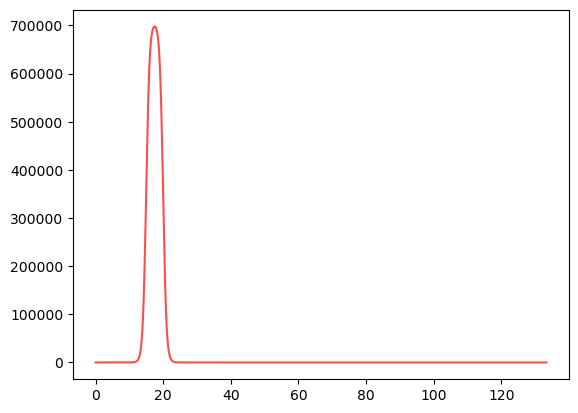

In [6]:
plt.plot(t*1e9, (x[2,:]+1j*x[3,:])*np.exp(1j*6.4e9*2*pi*t),color=(1,0,0,0.7),label='3WM drive')
plt.show()

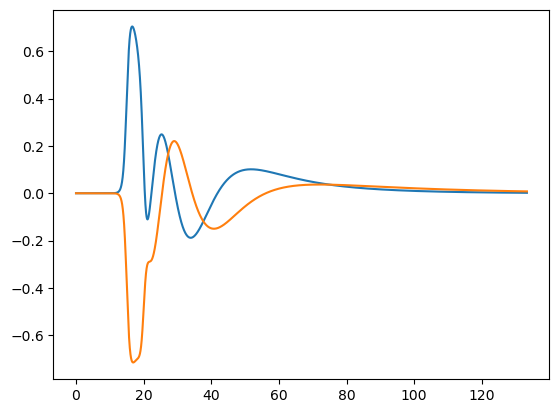

In [7]:
sqrtka = sim.param_dict_nosweep['sqrtka']

aout_I = x[2,:] + sqrtka*x[6,:]
aout_Q = x[3,:] + sqrtka*x[7,:]

plt.plot(t*1e9, (aout_I+1j*aout_Q)*np.exp(1j*6.4e9*2*pi*t)/np.max(aout_I))
plt.plot(t*1e9, (aout_I+1j*aout_Q)*np.exp(1j*6.4e9*2*pi*t+1j*np.pi/2)/np.max(aout_I))
plt.show()
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (arb. u.)')
plt.grid()

In [8]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [00:14<00:00, 1426.19it/s]


 
...finished GPU solve!


This step below is kind of hacky - I need to better implement different decimation frequencies (although the demodulation will always be one frequency - you can just rerun sim if you need more)

In [195]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

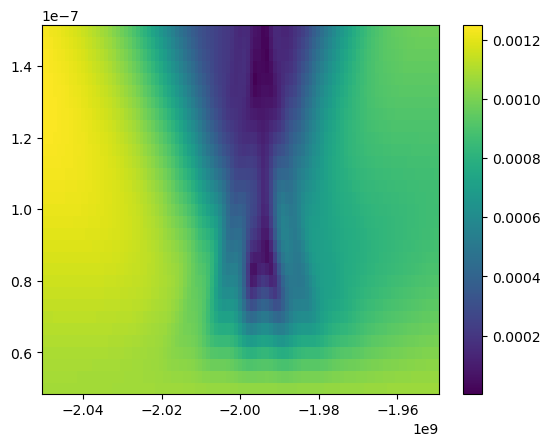

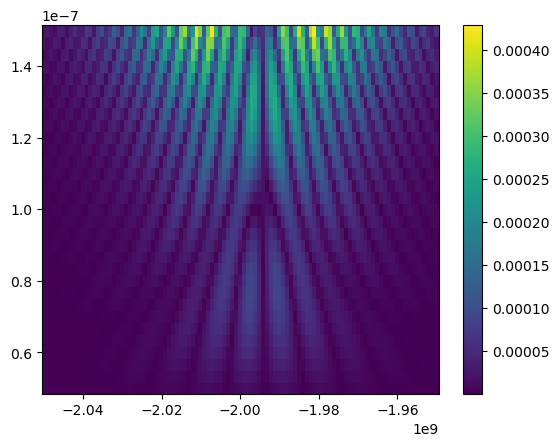

In [196]:
a_nbar = np.sqrt(Id[6,:]**2+Qd[6,:]**2)
b_nbar = np.sqrt(Id[8,:]**2+Qd[8,:]**2)

a_separation = np.sqrt((Id[6,1,:,:,:]-Id[6,0,:,:,:])**2 + (Qd[6,1,:,:,:]-Qd[6,0,:,:,:])**2)
b_separation = np.sqrt((Id[8,1,:,:,:]-Id[8,0,:,:,:])**2 + (Qd[8,1,:,:,:]-Qd[8,0,:,:,:])**2)

wC1 = sim.paramsweep_dict['wC1']
stopC1 = sim.paramsweep_dict['stopC1']

wC1_i = 28
amplC1_i = 10
qb_state = 0

plt.figure(4)
plt.pcolor(wC1/(2*np.pi), stopC1, a_nbar[qb_state,:, :,-1].transpose())
plt.colorbar()
plt.show()

plt.figure(5)
plt.pcolor(wC1/(2*np.pi), stopC1, b_nbar[qb_state,:, :,-1].transpose())
plt.colorbar()
plt.show()


## One-way kerr conversion

In [256]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.4e9*2*pi)
sim.add_param('wb', 5.35e9*2*pi)
sim.add_param('wc', 7.5e9*2*pi, is_excitation=True)
sim.add_param('logchi', 6) # in MHz
sim.add_param('sqrtka', np.sqrt(1e6 * 2 * np.pi)) # in MHz
sim.add_param('sqrtkb', np.sqrt(1e7 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(5e6 * 2 * np.pi))
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 0.1e6 * 2 * np.pi)
sim.add_paramsweep('qbstate', -1, 1, 2)

sim.add_param('amplR',  5e6)  # 0 - readout drive
sim.add_param('amplC1', 1)  # 6 - c1
sim.add_param('amplG', 0.02)  # 18 - gain
sim.add_param('amplC2', 0.0)  # 12 - c2
sim.add_param('wR', 6.40e9 * 2 * np.pi)  # 1
sim.add_param('wC1', -1.00e9*2*np.pi)  # 7
sim.add_param('wG', 8.0e9 * 2 * np.pi)  # 19
sim.add_param('wC2', 3.5e9 * 2 * np.pi)  # 13
sim.add_param('rampR', 1e-9)  # 2
sim.add_param('rampC1', 3e-9)  # 8
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startR', 15e-9)  # 3
sim.add_param('stopR', 20e-9)  # 4
sim.add_param('startC1', 45e-9)  # 9
sim.add_param('stopC1', 200e-9)  # 10
sim.add_param('startG', 0e-9)  # 21
sim.add_param('stopG', 200e-9)  # 22
sim.add_param('startC2', 190e-9)  # 15
sim.add_param('stopC2', 195e-9)  # 16
sim.add_param('phaseR', -np.pi / 4)  # 5
sim.add_param('phaseC1', np.pi / 3)  # 11
sim.add_param('phaseG', np.pi * 0.88)  # 23
sim.add_param('phaseC2', 0.0)  # 17

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('s0', C1pulse)
sim.add_EOM('ain', Rpulse)
sim.add_EOM('s2', Gpulse)

sim.add_EOM('a', '-1j*(wa+(10**logchi)*2*pi*qbstate)*a - 1j*gab*b*conjugate(s0) - ain*sqrtka - (sqrtka**2/2)*a')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*s0 - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s2 - 1j*b*g4*abs(b)**2')
sim.set_solve_type('decimate')

sim.specify_time(20, 2000, d_factor=10)

sim.validate()

Simulation validation success!


In [257]:
x, t = sim.quick_trace()

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


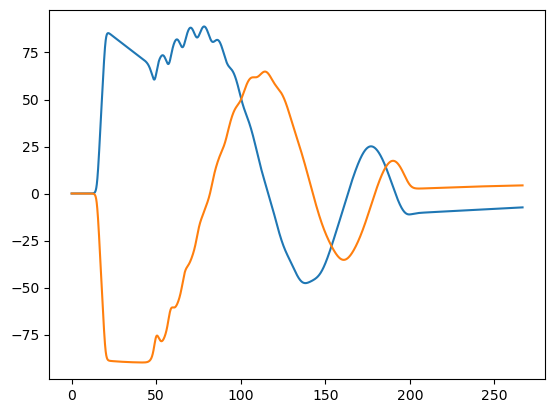

In [258]:
plt.plot(t*1e9, np.real((x[6,:]+1j*x[7,:])*np.exp(1j*6.4e9*2*pi*t)))
plt.plot(t*1e9, np.imag((x[6,:]+1j*x[7,:])*np.exp(1j*6.4e9*2*pi*t)))
plt.show()

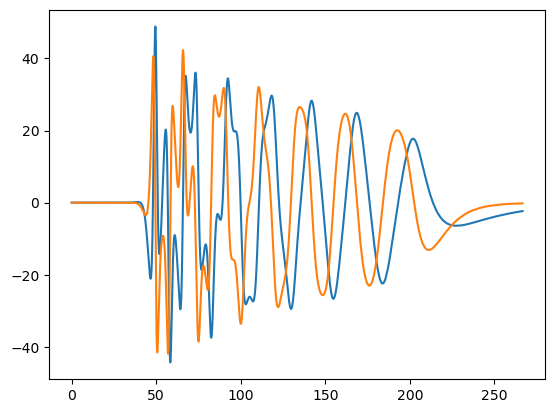

In [259]:
plt.plot(t*1e9, np.real((x[8,:]+1j*x[9,:])*np.exp(1j*5.35e9*2*pi*t)))
plt.plot(t*1e9, np.imag((x[8,:]+1j*x[9,:])*np.exp(1j*5.35e9*2*pi*t)))
plt.show()